# Size Estimation in Bins — Using .pkl data

In [15]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import pickle
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

print(f'TensorFlow: {tf.__version__}')
print(f'TF Hub:     {hub.__version__}')
print(f'GPUs:       {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.21.0
TF Hub:     0.16.1
GPUs:       []


## Configuration

In [ ]:
TRAIN_PKL = '../data/folds-w-meta.pkl'
TEST_PKL  = '../data/test-w-meta.pkl'

EFFNET_LITE0_URL    = 'https://tfhub.dev/tensorflow/efficientnet/lite0/feature-vector/2'
ESTIMATE_IMAGE_SIZE = (224, 224)   
BATCH_SIZE          = 32
ESTIMATOR_EPOCHS    = 10            

# Train / val / test split
TRAIN_FOLDS = list(range(0, 9))    # folds 0–8 (since not doing 10-fold cross-validation)
VAL_FOLDS   = [9]                  # fold 9

# Size-bin definitions (edges in mm, labels in cm) ─────────────────────────
# Silva et al. original 10-bin layout: 5cm bins up to 40cm, then 10cm bins to 70cm.
### Updated bin edges and labels to include more bins for better resolution
BIN_EDGES  = [250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 800, 900]
BIN_LABELS = ['25', '30', '35', '40', '45', '50', '55', '60', '65', '70', '80', '90']
NUM_SIZE_BINS = len(BIN_LABELS)

def length_to_bin(length_mm):
    """Map a length in mm to a size-bin index. Returns None if out of range."""
    for i, edge in enumerate(BIN_EDGES):
        if length_mm <= edge:
            return i
    return None  # fish longer than 700 mm — will be dropped

## Load pkl files

In [17]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')

train_pkl_folds = load_pkl(TRAIN_PKL)
test_pkl_folds  = load_pkl(TEST_PKL)

print(f'Train pkl folds: {len(train_pkl_folds)}')
print(f'Keys per fold:   {list(train_pkl_folds[0].keys())}')
print(f'Fold 0 size:     {len(train_pkl_folds[0]["data"])} fish')
print(f'Test pkl folds:  {len(test_pkl_folds)}')

Train pkl folds: 10
Keys per fold:   ['fold', 'length', 'weight', 'source', 'girth', 'data', 'id', 'class']
Fold 0 size:     63 fish
Test pkl folds:  1


In [18]:
fold0 = train_pkl_folds[0]
raw = fold0['data'][0]
print(f'Raw type:  {type(raw)}')
print(f'Raw shape: {np.array(raw).shape}')
print(f'Total elements: {np.array(raw).size}')

Raw type:  <class 'numpy.ndarray'>
Raw shape: (9, 75, 200, 3)
Total elements: 405000


## Convert pkl folds to (image, label) arrays

Each `data` entry is a flattened image; we reshape to `(-1, 200, 3)` to recover RGB pixels, then resize to 224×224 for EfficientNet-Lite0. Entries with missing or out-of-range lengths are dropped (calibration fish, oversized fish).

In [19]:
def folds_to_arrays(folds, fold_indices=None):
    """
    Unpack the listed folds into (N, 224, 224, 3) float32 images and (N,) int bin labels.
    Each fish contributes 9 image entries (one per scanner view).
    """
    if fold_indices is None:
        fold_indices = list(range(len(folds)))
    X, y = [], []
    skipped_fish = 0
    for fi in fold_indices:
        fold = folds[fi]
        for i, raw in enumerate(fold['data']):           # raw: (9, 75, 200, 3)
            length = fold['length'][i]
            if length is None or str(length).strip() in ('', 'NA'):
                skipped_fish += 1; continue
            bin_idx = length_to_bin(float(length))
            if bin_idx is None:
                skipped_fish += 1; continue

            # Each fish has 9 views — emit one example per view
            for view_idx in range(raw.shape[0]):
                img = raw[view_idx].astype(np.float32)   # (75, 200, 3)
                img_resized = tf.image.resize(img, ESTIMATE_IMAGE_SIZE).numpy()
                X.append(img_resized)
                y.append(bin_idx)

    print(f'  Loaded {len(X)} images from {len(X)//9} fish, skipped {skipped_fish} fish')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

In [20]:
X_all, y_all = folds_to_arrays(train_pkl_folds + test_pkl_folds)
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.2)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

print(f'\nTrain: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print(f'Train bin counts: {np.bincount(y_train, minlength=NUM_SIZE_BINS)}')
print(f'Val   bin counts: {np.bincount(y_val,   minlength=NUM_SIZE_BINS)}')
print(f'Test  bin counts: {np.bincount(y_test,  minlength=NUM_SIZE_BINS)}')

  Loaded 6237 images from 693 fish, skipped 1 fish

Train: 4989  Val: 624  Test: 624
Train bin counts: [ 71 115 327 551 951 935 702 470 325 273 201  68]
Val   bin counts: [  5  12  42  68 102 128  81  58  36  47  34  11]
Test  bin counts: [  5   8  45  83 108 107  90  66  35  40  26  11]


In [21]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
                .shuffle(len(X_train), seed=12).batch(BATCH_SIZE).prefetch(AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))
test_ds  = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))

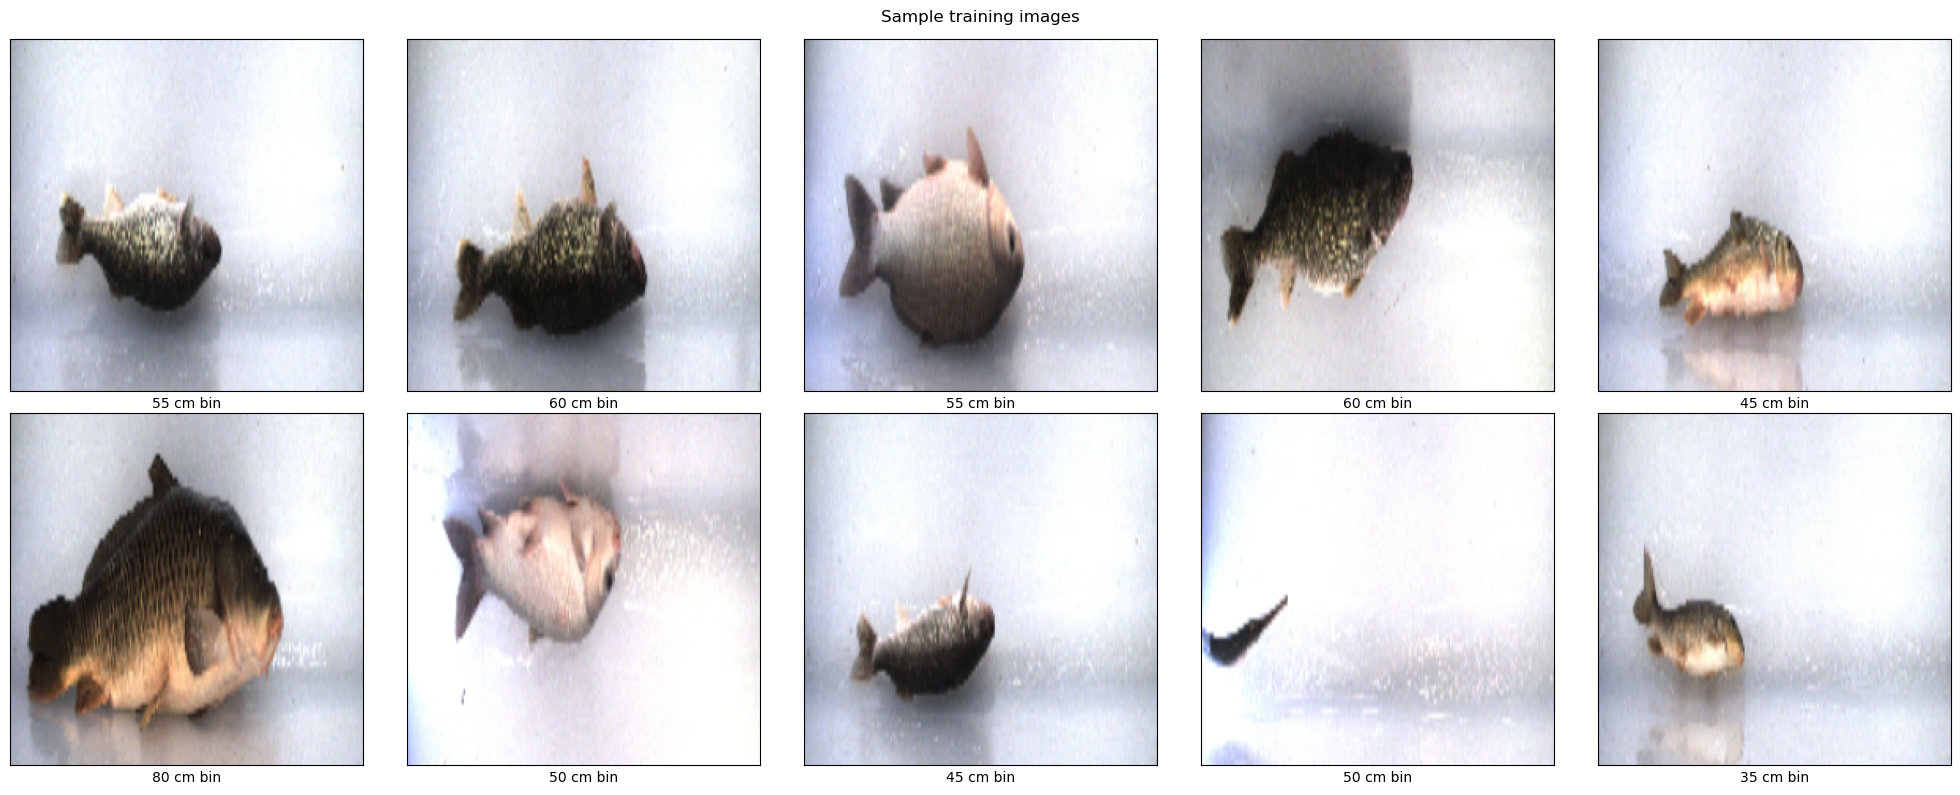

In [22]:
# Preview a few training images
plt.figure(figsize=(20, 8))
for imgs, lbls in train_ds.take(1):
    for i in range(min(10, imgs.shape[0])):
        plt.subplot(2, 5, i + 1)
        plt.xticks([]); plt.yticks([]); plt.grid(False)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        plt.xlabel(f'{BIN_LABELS[lbls[i].numpy()]} cm bin')
plt.suptitle('Sample training images')
plt.tight_layout(); plt.show()

## Build model — EfficientNet-Lite0

In [23]:
def build_estimator(num_classes, trainable_backbone=False):
    backbone = hub.KerasLayer(
        EFFNET_LITE0_URL,
        trainable=trainable_backbone,
        input_shape=ESTIMATE_IMAGE_SIZE + (3,),
    )
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=ESTIMATE_IMAGE_SIZE + (3,)),
        tf.keras.layers.Rescaling(1.0 / 255.0),   # [0,255] → [0,1] for Lite0
        backbone,
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

estimator = build_estimator(NUM_SIZE_BINS, trainable_backbone=False)
estimator.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 keras_layer (KerasLayer)    (None, 1280)              3413024   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 12)                15372     
                                                                 
Total params: 3428396 (13.08 MB)
Trainable params: 15372 (60.05 KB)
Non-trainable params: 3413024 (13.02 MB)
_________________________________________________________________


## Train

In [25]:
# Class weights for bin imbalance (small/large fish are rare in Silva's data)
unique_bins = np.unique(y_train)
weights_arr = compute_class_weight('balanced', classes=unique_bins, y=y_train)
class_weights = dict(zip(unique_bins.tolist(), weights_arr.tolist()))
for c in range(NUM_SIZE_BINS):
    class_weights.setdefault(c, 1.0)
print(f'Class weights: {class_weights}')

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history = estimator.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ESTIMATOR_EPOCHS,
    # Below options not used by Silva but do improve accuracy
    class_weight=class_weights,
    callbacks=[early_stop],
)

Class weights: {0: 5.855633802816901, 1: 3.615217391304348, 2: 1.2714067278287462, 3: 0.7545372050816697, 4: 0.4371713985278654, 5: 0.4446524064171123, 6: 0.5922364672364673, 7: 0.8845744680851064, 8: 1.2792307692307692, 9: 1.5228937728937728, 10: 2.068407960199005, 11: 6.113970588235294}
Epoch 1/5



156/156 [==============================] - 17s 105ms/step - loss: 1.8894 - accuracy: 0.2768 - val_loss: 1.6203 - val_accuracy: 0.4359
Epoch 2/5
156/156 [==============================] - 16s 103ms/step - loss: 1.3724 - accuracy: 0.4384 - val_loss: 1.4463 - val_accuracy: 0.4904
Epoch 3/5
156/156 [==============================] - 16s 102ms/step - loss: 1.2053 - accuracy: 0.4817 - val_loss: 1.4073 - val_accuracy: 0.4856
Epoch 4/5
156/156 [==============================] - 16s 102ms/step - loss: 1.0999 - accuracy: 0.5159 - val_loss: 1.3209 - val_accuracy: 0.5128
Epoch 5/5
156/156 [==============================] - 16s 100ms/step - loss: 0.9978 - accuracy: 0.5542 - val_loss: 1.2706 - val_accuracy: 0.5353


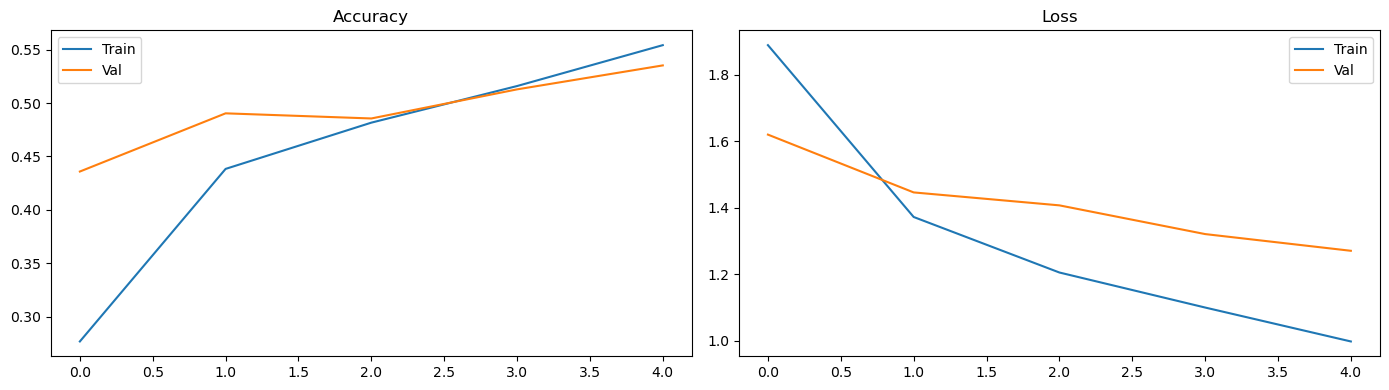

Train  — loss: 1.1270, accuracy: 61.21%
Val    — loss: 1.2706, accuracy: 53.53%
Test   — loss: 1.2890, accuracy: 51.60%


In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend()
plt.tight_layout(); plt.show()

for ds, name in [(train_ds, 'Train'), (val_ds, 'Val'), (test_ds, 'Test')]:
    loss, acc = estimator.evaluate(ds, verbose=0)
    print(f'{name:<6} — loss: {loss:.4f}, accuracy: {acc:.2%}')

## Confusion matrix

Per-image accuracy: 41.94%
Per-fish accuracy:  47.89%


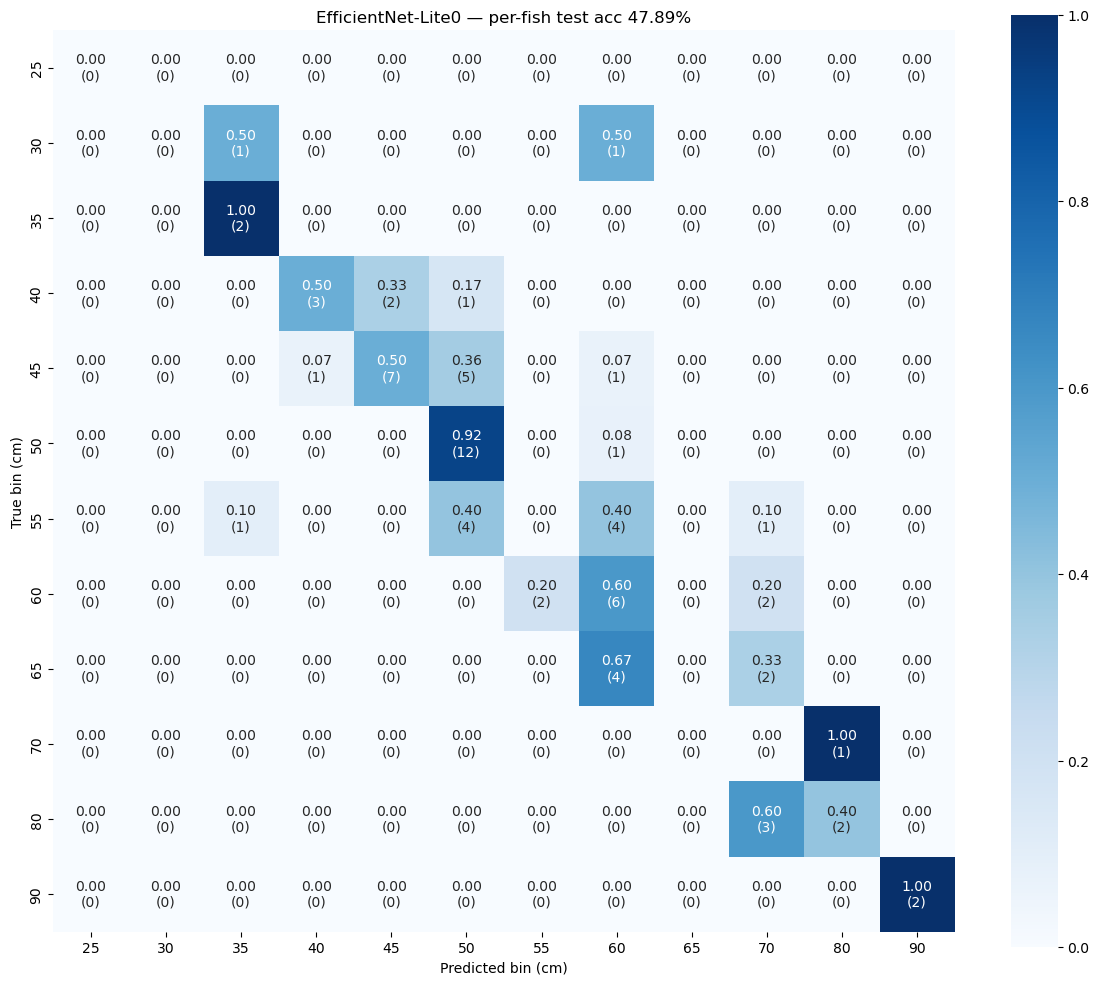

In [ ]:
# Per-fish accuracy CM: average the 9 view-level softmaxes per fish

probs = estimator.predict(X_test, verbose=0)
y_pred = np.argmax(probs, axis=1)

per_image_acc = np.mean(y_test == y_pred)
print(f'Per-image accuracy: {per_image_acc:.2%}')

# Per-fish accuracy: average the 9 view-level softmaxes per fish 
probs_per_fish  = probs.reshape(-1, 9, NUM_SIZE_BINS).mean(axis=1)   
y_pred_per_fish = np.argmax(probs_per_fish, axis=1)
y_true_per_fish = y_test.reshape(-1, 9)[:, 0]                       
per_fish_acc    = np.mean(y_pred_per_fish == y_true_per_fish)
print(f'Per-fish accuracy:  {per_fish_acc:.2%}')

# Using per-fish for CM since it's the fairer comparison to Silva (Silva only had 1 image per-fish)
cm      = confusion_matrix(y_true_per_fish, y_pred_per_fish, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1)
plt.title(f'EfficientNet-Lite0 — per-fish test acc {per_fish_acc:.2%}')
plt.ylabel('True bin (cm)'); plt.xlabel('Predicted bin (cm)')
plt.tight_layout(); plt.show()

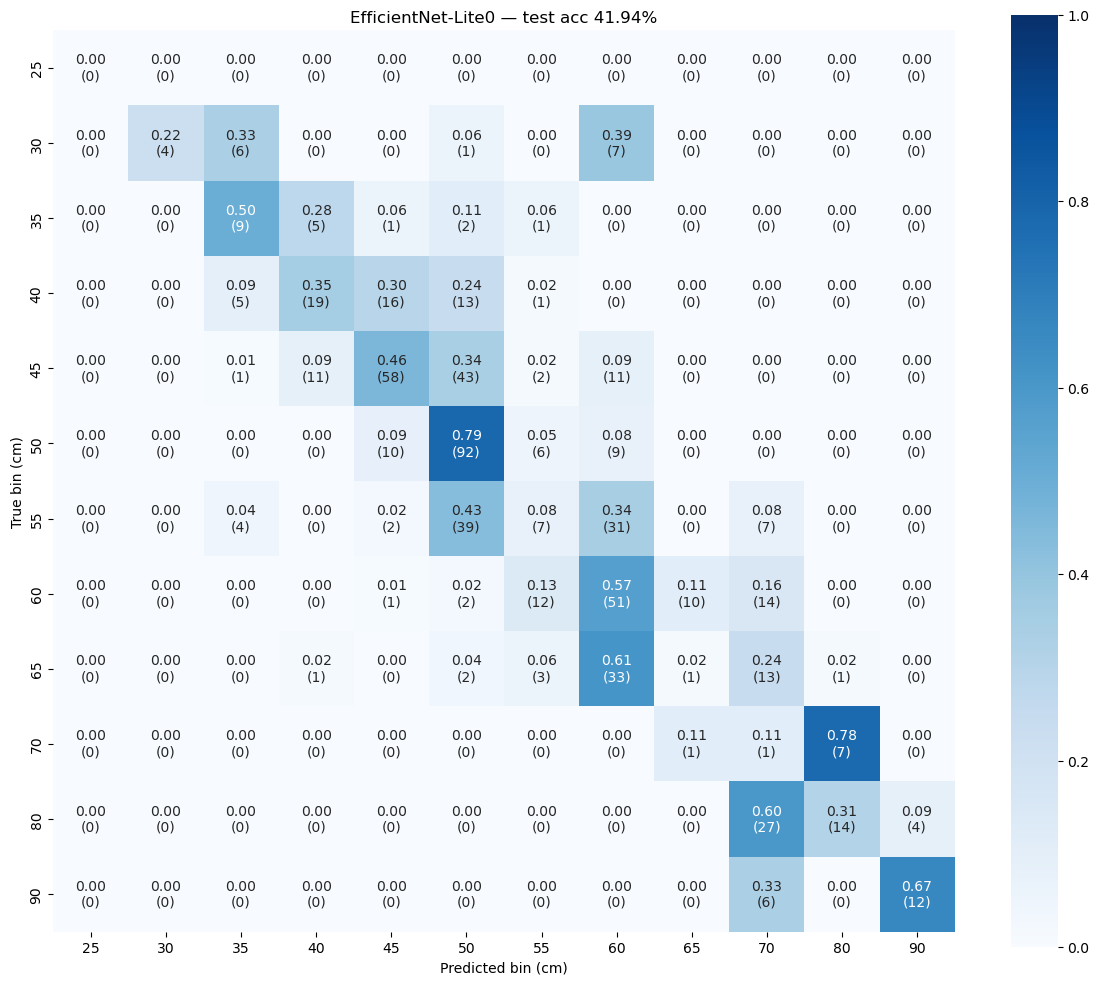

In [25]:
# Per-image predictions

y_pred = np.argmax(estimator.predict(X_test, verbose=0), axis=1)

cm      = confusion_matrix(y_test, y_pred, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

test_acc = np.mean(y_test == y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1)
plt.title(f'EfficientNet-Lite0 — test acc {test_acc:.2%}')
plt.ylabel('True bin (cm)'); plt.xlabel('Predicted bin (cm)')
plt.tight_layout(); plt.show()

In [26]:
SAVE_PATH = './models/estimator_bins.keras'
estimator.save(SAVE_PATH)
print(f'Saved model to {SAVE_PATH}')

Saved model to ./models/estimator_bins.keras


# Evaluation Code

In [ ]:
# ── 20-run experiment (replicating Silva's method validation) ─────────────
NUM_RUNS = 20
ESTIMATOR_EPOCHS = 10
AUTOTUNE = tf.data.AUTOTUNE

# 1. Pool ALL data to match Silva's method
print('Pooling all data...')
X_all, y_all = folds_to_arrays(train_pkl_folds + test_pkl_folds)
print(f'Total: {X_all.shape[0]} images')
print(f'Bin counts: {np.bincount(y_all, minlength=NUM_SIZE_BINS)}\n')

results = []
all_cm = np.zeros((NUM_SIZE_BINS, NUM_SIZE_BINS), dtype=np.float64)

for run in range(NUM_RUNS):
    seed = run
    print(f'═══ Run {run + 1}/{NUM_RUNS}  (seed={seed}) ═══')

    # 80/10/10 split (matching Silva)
    X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.2, random_state=seed)
    X_val, X_test, y_val, y_test       = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)

    train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
                .shuffle(len(X_train), seed=seed).batch(BATCH_SIZE).prefetch(AUTOTUNE))
    val_ds   = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))
    test_ds  = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))

    model = build_estimator(NUM_SIZE_BINS, trainable_backbone=False)
    model.fit(train_ds, validation_data=val_ds, epochs=ESTIMATOR_EPOCHS, verbose=0)

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    results.append({
        'run': run + 1,
        'seed': seed,
        'accuracy': test_acc,
        'loss': test_loss,
    })
    print(f'  Accuracy: {test_acc:.2%}  Loss: {test_loss:.4f}\n')

    cm = confusion_matrix(y_test, y_pred, labels=list(range(NUM_SIZE_BINS)))
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_sum == 0, 0, cm / np.where(row_sum == 0, 1, row_sum))
    all_cm += cm_norm

    del model, probs
    tf.keras.backend.clear_session()

Pooling all data...
  Loaded 6237 images from 693 fish, skipped 1 fish
Total: 6237 images
Bin counts: [  81  135  414  702 1161 1170  873  594  396  360  261   90]

═══ Run 1/20  (seed=0) ═══
  Accuracy: 58.81%  Loss: 1.0408

═══ Run 2/20  (seed=1) ═══
  Accuracy: 55.61%  Loss: 1.1014

═══ Run 3/20  (seed=2) ═══
  Accuracy: 54.65%  Loss: 1.1097

═══ Run 4/20  (seed=3) ═══
  Accuracy: 59.46%  Loss: 1.0539

═══ Run 5/20  (seed=4) ═══
  Accuracy: 59.94%  Loss: 1.0112

═══ Run 6/20  (seed=5) ═══
  Accuracy: 55.13%  Loss: 1.0875

═══ Run 7/20  (seed=6) ═══
  Accuracy: 60.74%  Loss: 1.0106

═══ Run 8/20  (seed=7) ═══
  Accuracy: 58.49%  Loss: 1.1033

═══ Run 9/20  (seed=8) ═══
  Accuracy: 60.10%  Loss: 1.0467

═══ Run 10/20  (seed=9) ═══
  Accuracy: 60.58%  Loss: 1.0195

═══ Run 11/20  (seed=10) ═══
  Accuracy: 57.37%  Loss: 1.0812

═══ Run 12/20  (seed=11) ═══
  Accuracy: 60.10%  Loss: 1.0629

═══ Run 13/20  (seed=12) ═══
  Accuracy: 61.54%  Loss: 1.0112

═══ Run 14/20  (seed=13) ═══
  Accu

In [31]:
# ── Summary table ────────────────────────────────────────────────────────
import pandas as pd

df = pd.DataFrame(results)
print(df.to_string(index=False))
print(f'\nAvg accuracy: {df["accuracy"].mean():.2%} ± {df["accuracy"].std():.2%}')
print(f'Loss: {df["loss"].mean():.4f} ± {df["loss"].std():.4f}')

 run  seed  accuracy     loss
   1     0  0.588141 1.040787
   2     1  0.556090 1.101382
   3     2  0.546474 1.109713
   4     3  0.594551 1.053859
   5     4  0.599359 1.011164
   6     5  0.551282 1.087545
   7     6  0.607372 1.010596
   8     7  0.584936 1.103303
   9     8  0.600962 1.046656
  10     9  0.605769 1.019520
  11    10  0.573718 1.081225
  12    11  0.600962 1.062866
  13    12  0.615385 1.011231
  14    13  0.594551 1.019415
  15    14  0.588141 1.061596
  16    15  0.588141 1.086111
  17    16  0.591346 1.014524
  18    17  0.541667 1.100746
  19    18  0.556090 1.099021
  20    19  0.578526 1.073443

Avg accuracy: 58.32% ± 2.19%
Loss: 1.0597 ± 0.0359


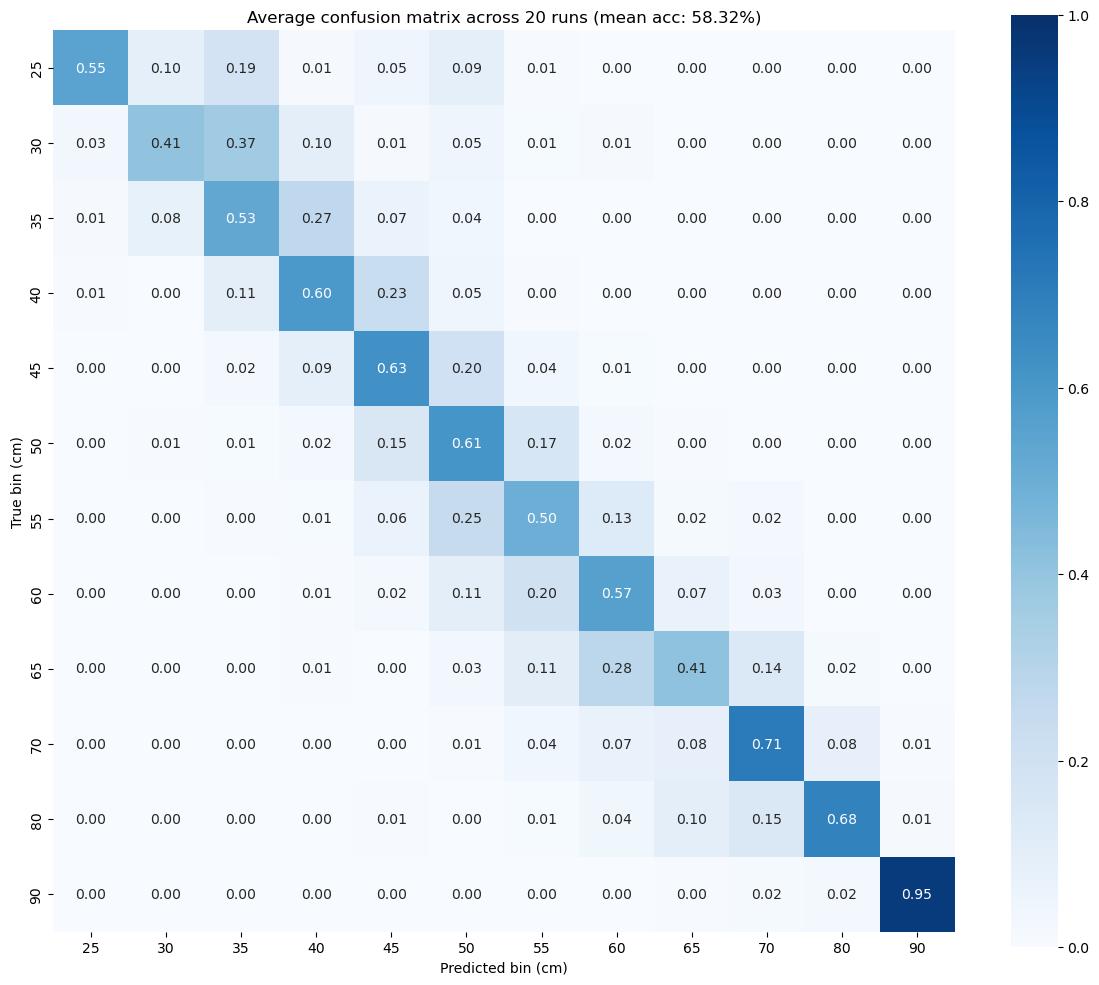

In [33]:
# ── Average confusion matrix across 20 runs ──────────────────────────────
avg_cm = all_cm / NUM_RUNS

plt.figure(figsize=(12, 10))
sns.heatmap(avg_cm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=True, fmt='.2f', square=True, vmin=0, vmax=1)
plt.title(f'Average confusion matrix across {NUM_RUNS} runs '
          f'(mean acc: {df["accuracy"].mean():.2%})')
plt.ylabel('True bin (cm)')
plt.xlabel('Predicted bin (cm)')
plt.tight_layout()
plt.show()